# VeriPromiseESG 2026 ESG 承諾驗證工作坊
## 使用 RoBERTa 進行多任務分類

**工作坊時間**: 約 60 分鐘  
**難度**: 中級（需具備基礎 Python 知識）

### 今天的學習目標
1. 了解 ESG（環境、社會、治理）承諾驗證任務
2. 掌握如何使用 RoBERTa 進行多標籤分類
3. 實作完整的訓練與評估流程

### 任務說明
給定一段 ESG 報告文字，模型需要同時預測四個欄位：
| 欄位 | 說明 | 類別 |
|------|------|------|
| \ | 是否有承諾 | Yes / No |
| \ | 承諾時程 | already / within_2_years / between_2_and_5_years / longer_than_5_years / N/A |
| \ | 是否有佐證 | Yes / No / N/A |
| \ | 佐證品質 | Clear / Not Clear / Misleading / N/A |

### Related Links
- Competition Main Website：https://veripromiseesg.github.io/
- AI CUP Main Website：https://www.aicup.tw/
- AI CUP Competition Registration Website：https://go.aicup.tw/
- AIDEA Competition Website：https://www.aidea-web.tw/aicup_veripromiseesg
### Reference Links
- SemEval-2025 Task 6: Multinational, Multilingual, Multi-Industry Promise Verification：https://aclanthology.org/2025.semeval-1.321/
- ML-Promise: A Multilingual Dataset for Corporate Promise Verification：https://aclanthology.org/2025.emnlp-main.1028/
- Multilingual Promise Verification in ESG Reports with Large Language Model Performance Evaluation：https://aclanthology.org/2025.rocling-main.32/
- NTCIR：https://research.nii.ac.jp/ntcir/index-en.html

## Step 1: 安裝套件

首先安裝必要的 Python 套件。在 Google Colab 上執行以下指令。

> **說明**：
> - `transformers` — HuggingFace 提供的預訓練模型庫
> - `torch` — PyTorch 深度學習框架
> - `scikit-learn` — 評估指標計算
> - `pandas` / `matplotlib` — 資料分析與視覺化

In [1]:
# 安裝/更新 transformers
!pip install transformers -q

import numpy as np
import torch
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import urllib.request
import json
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print('套件載入完成！')
print(f'PyTorch 版本: {torch.__version__}')
print(f'CUDA 可用: {torch.cuda.is_available()}')

套件載入完成！
PyTorch 版本: 2.10.0+cu128
CUDA 可用: True


In [2]:
# 動態下載 Google Noto Sans 繁體中文字型
!wget -q -O NotoSansTC.otf https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf

# 載入字型至 Matplotlib
import matplotlib.font_manager as fm
fm.fontManager.addfont('NotoSansTC.otf')
matplotlib.rc('font', family='Noto Sans CJK TC')
plt.rcParams['axes.unicode_minus'] = False

print("Kaggle 中文字型設定完成！")

Kaggle 中文字型設定完成！


## Step 2: 設定超參數與標籤對應

在開始之前，我們先定義所有重要的超參數與標籤映射表。

### 重要參數說明
- **MODEL_NAME**: 使用 `hfl/chinese-roberta-wwm-ext`，這是哈工大發布的中文 RoBERTa 模型
- **MAX_LEN**: 輸入文字的最大 Token 長度（256）
- **BATCH_SIZE**: 每次訓練的樣本數（16）
- **EPOCHS**: 訓練完整資料集的次數（5）
- **LR**: 學習率，建議 RoBERTa fine-tuning 使用 2e-5

### 為什麼用 chinese-roberta-wwm-ext？
RoBERTa（Robustly Optimized BERT Pretraining Approach）是 BERT 的改進版本。
- 移除了 Next Sentence Prediction（NSP）任務
- 使用更大的 batch size 與更長的訓練時間
- 採用全詞遮罩（Whole Word Masking, WWM）策略，更適合中文
- 在多項中文 NLP 任務上優於 bert-base-chinese

In [3]:
# ============================================================
# 超參數設定
# ============================================================
MODEL_NAME = "hfl/chinese-roberta-wwm-ext"
MAX_LEN = 512
BATCH_SIZE = 16    # 資料集較小（1000筆），使用小 batch size
EPOCHS = 10       # 資料少，多訓練幾個 epoch
LR = 2e-5

# 四個預測欄位及其標籤（依照競賽官方規格定義）
EVAL_FIELDS = {
    "promise_status": ["Yes", "No"],
    "verification_timeline": ["already", "within_2_years", "between_2_and_5_years", "more_than_5_years", "N/A"],
    "evidence_status": ["Yes", "No", "N/A"],
    "evidence_quality": ["Clear", "Not Clear", "Misleading", "N/A"]
}

# 各欄位的評分權重（依照競賽規則）
FIELD_WEIGHTS = {
    "promise_status": 0.2,
    "verification_timeline": 0.15,
    "evidence_status": 0.3,
    "evidence_quality": 0.35
}

# 建立標籤到 ID 的映射
label2id = {field: {label: i for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
id2label = {field: {i: label for i, label in enumerate(labels)} for field, labels in EVAL_FIELDS.items()}
num_labels = {field: len(labels) for field, labels in EVAL_FIELDS.items()}

print('超參數設定完成！')
print(f'使用模型: {MODEL_NAME}')
print(f'最大長度: {MAX_LEN}')
print(f'批次大小: {BATCH_SIZE}')
print(f'訓練輪數: {EPOCHS}')
print(f'標籤數量: {num_labels}')

超參數設定完成！
使用模型: hfl/chinese-roberta-wwm-ext
最大長度: 512
批次大小: 16
訓練輪數: 10
標籤數量: {'promise_status': 2, 'verification_timeline': 5, 'evidence_status': 3, 'evidence_quality': 4}


---

## Step 3: 載入資料
載入剛才下載的 JSON 檔案，並切分為訓練集（80%）與驗證集（20%）。

> **說明**：這份資料共 1,000 筆，來自台灣上市公司的 ESG 永續報告書。

In [5]:
import pandas as pd
import json
from sklearn.model_selection import KFold

TRAIN_PATH = "/kaggle/input/datasets/raingarden/dataset-1/csv/vpesg_4k_train_1000.csv"
VAL_PATH = "/kaggle/input/datasets/raingarden/dataset-1/csv/vpesg4k_val_1000.csv"  

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)

# 只對這四個欄位填值
for field in ['verification_timeline', 'evidence_status', 'evidence_quality']:
    train_df[field] = train_df[field].fillna('N/A')
    val_df[field] = val_df[field].fillna('N/A')

# ============================================================
# K-Fold：把 train + val 合併成一個資料池，重新切分成 K 份
# 沒有 company/ticker 欄位，用一般 KFold（非 GroupKFold）
# ============================================================
N_FOLDS = 5
all_df = pd.concat([train_df, val_df], ignore_index=True)
all_data = all_df.to_dict('records')

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
fold_indices = list(kf.split(all_data))

# 保留原始 train_data / val_data 名稱以維持其他 cell 相容（先用第一折初始化，後續訓練迴圈會逐折覆寫）
train_idx, val_idx = fold_indices[0]
train_data = [all_data[i] for i in train_idx]
val_data = [all_data[i] for i in val_idx]
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("🎉 資料載入成功！")
print(f"   合併後總資料量 (all_data): {len(all_data)} 筆")
print(f"   K-Fold 折數: {N_FOLDS}")
print(f"   Fold 0 訓練集: {len(train_data)} 筆, 驗證集: {len(val_data)} 筆")

# 順便偷看一眼資料結構是否正常
print("\n💡 訓練集前兩筆資料預覽：")
display(train_df.head(2))

🎉 資料載入成功！
   合併後總資料量 (all_data): 2000 筆
   K-Fold 折數: 5
   Fold 0 訓練集: 1600 筆, 驗證集: 400 筆

💡 訓練集前兩筆資料預覽：


,id,data,esg_type,promise_status,promise_string,verification_timeline,evidence_status,evidence_string,evidence_quality,company,ticker,page_number,pdf_url,company_source
0,10001,聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持...,S,Yes,為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共...,already,No,NaN,N/A,mediatek,2454,48,https://d86o2zu8ugzlg.cloudfront.net/reports/C...,https://corp.mediatek.tw/about/sustainability
1,10002,在與供應商攜手邁向永續發展的過程中，台泥致力於建立一套以合作為基礎的價值體體系。核心原則是推...,E,Yes,台泥致力於建立一套以合作為基礎的價值體體系。,between_2_and_5_years,Yes,核心原則是推動供應鏈的低碳轉型，同時維護人權、保護環境和促進生物多樣性，以建立永續的合作夥伴關係。,Not Clear,tcc,1101,32,https://media.taiwancement.com/web_tcc/comm/pd...,https://www.tccgroupholdings.com/tw/esgReport....


---

## Step 4: 探索性資料分析（EDA）

在訓練模型前，先深入了解資料的特性，這一步非常重要！

我們要觀察：
1. 資料的欄位結構
2. 各標籤的分佈（是否不均衡？）
3. 文字長度分佈
4. 範例資料內容

In [6]:
# 觀察單筆資料結構
sample = train_df.iloc[0]
print("範例資料欄位：")
print("-" * 50)
for key, value in sample.items():
    if key == "data":
        print(f"  {key}: {str(value)[:100]}...")
    else:
        print(f"  {key}: {value}")

範例資料欄位：
--------------------------------------------------
  id: 10001
  data: 聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性...
  esg_type: S
  promise_status: Yes
  promise_string: 為支持同仁與其家人度過人生不同階段，自 2024 年起提供女性員工在分娩前後計有 12 週共 84 天的產假；男性員工則可於其配偶懷孕期間陪同產檢或生（流）產日及前後 15 日間請假陪伴，兩者合計共有 10 天陪產（檢）假可運用，陪產（檢）假期間工資照常給付。
  verification_timeline: already
  evidence_status: No
  evidence_string: nan
  evidence_quality: N/A
  company: mediatek
  ticker: 2454
  page_number: 48
  pdf_url: https://d86o2zu8ugzlg.cloudfront.net/reports/CSR/2024-MediaTek-ESG-Report_Chinese.pdf
  company_source: https://corp.mediatek.tw/about/sustainability


In [7]:
# 轉換為 DataFrame 方便分析
train_df = pd.DataFrame(train_data)
val_df = pd.DataFrame(val_data)

print("訓練集欄位類型：")
print(train_df.dtypes)
print(f"\n訓練集欄位：{list(train_df.columns)}")

訓練集欄位類型：
id                        int64
data                     object
esg_type                 object
promise_status           object
promise_string           object
verification_timeline    object
evidence_status          object
evidence_string          object
evidence_quality         object
company                  object
ticker                    int64
page_number               int64
pdf_url                  object
company_source           object
dtype: object

訓練集欄位：['id', 'data', 'esg_type', 'promise_status', 'promise_string', 'verification_timeline', 'evidence_status', 'evidence_string', 'evidence_quality', 'company', 'ticker', 'page_number', 'pdf_url', 'company_source']


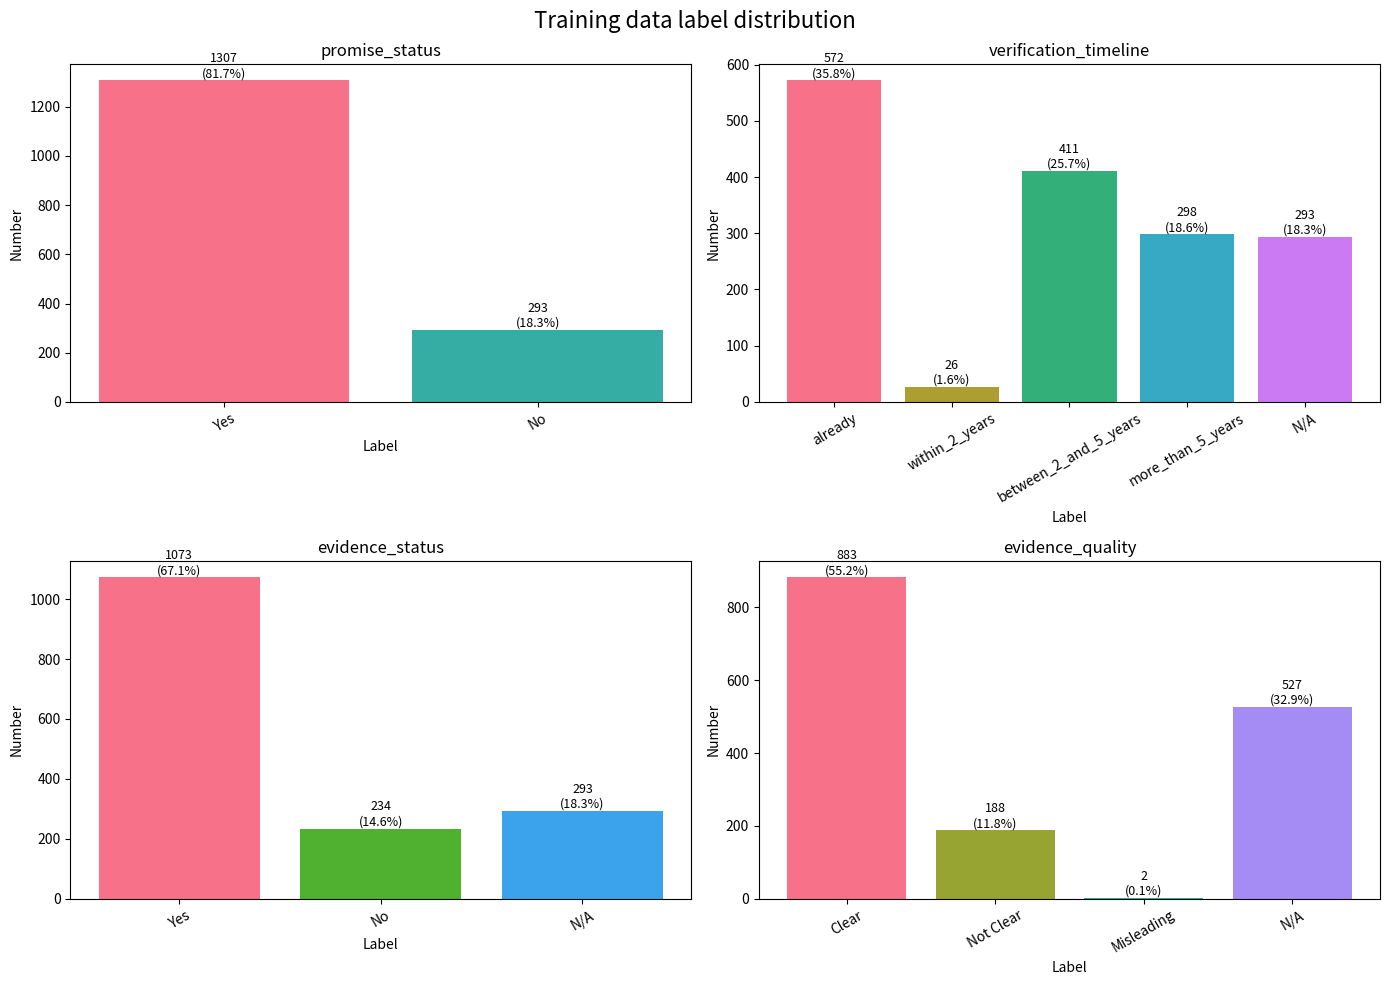

觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數


In [8]:
# 視覺化各欄位的標籤分佈
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training data label distribution", fontsize=16, fontweight='bold')

for idx, (field, labels) in enumerate(EVAL_FIELDS.items()):
    ax = axes[idx // 2][idx % 2]

    counts = Counter(train_df[field])
    ordered_counts = {label: counts.get(label, 0) for label in labels}

    bars = ax.bar(ordered_counts.keys(), ordered_counts.values(),
                   color=sns.color_palette("husl", len(labels)))
    ax.set_title(f"{field}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Label")
    ax.set_ylabel("Number")
    ax.tick_params(axis='x', rotation=30)

    # 在每個bar上顯示數量
    for bar, (label, count) in zip(bars, ordered_counts.items()):
        total = sum(ordered_counts.values())
        pct = count / total * 100
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("觀察：某些類別樣本數量差異很大（類別不均衡），這會影響 Macro F1 分數")

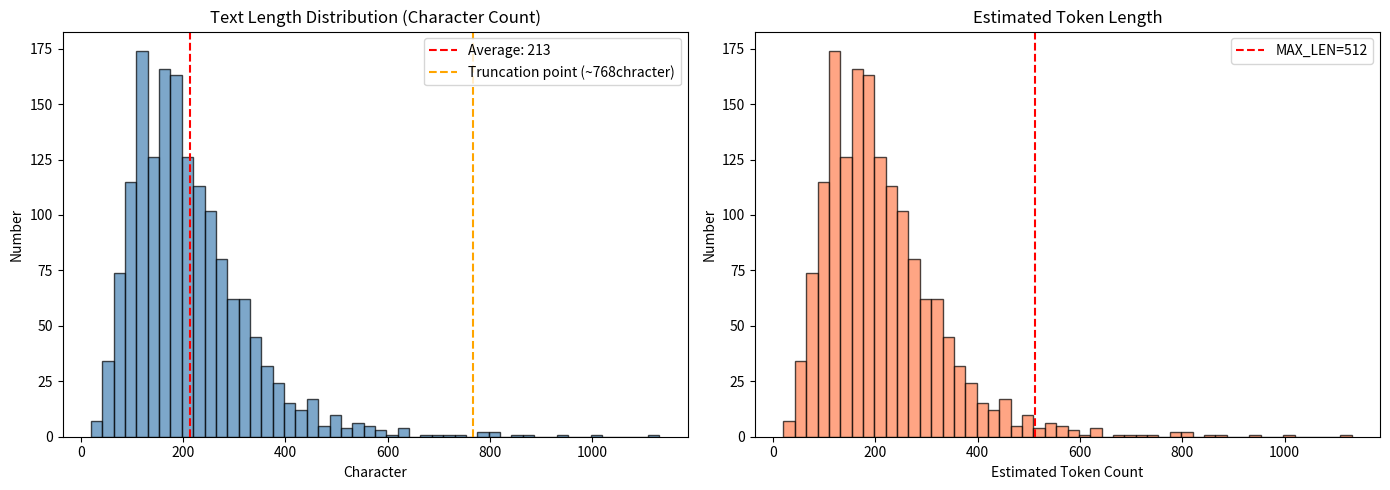

超過 MAX_LEN=512 的樣本數: 36 (2.2%)
   這些文字將被截斷，可能損失尾端資訊


In [9]:
# 分析文字長度分佈（字元數）
train_df['text_length'] = train_df['data'].apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train_df['text_length'], bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].axvline(train_df['text_length'].mean(), color='red', linestyle='--',
                label=f"Average: {train_df['text_length'].mean():.0f}")
axes[0].axvline(MAX_LEN * 1.5, color='orange', linestyle='--',
                label=f"Truncation point (~{MAX_LEN * 1.5:.0f}chracter)")
axes[0].set_title("Text Length Distribution (Character Count)")
axes[0].set_xlabel("Character")
axes[0].set_ylabel("Number")
axes[0].legend()

# Token 長度估算（中文約 1字 = 1 token）
axes[1].hist(train_df['text_length'], bins=50, color='coral', alpha=0.7, edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f"MAX_LEN={MAX_LEN}")
axes[1].set_title("Estimated Token Length")
axes[1].set_xlabel("Estimated Token Count")
axes[1].set_ylabel("Number")
axes[1].legend()

plt.tight_layout()
plt.show()

truncated = (train_df['text_length'] > MAX_LEN).sum()
print(f"超過 MAX_LEN={MAX_LEN} 的樣本數: {truncated} ({truncated/len(train_df)*100:.1f}%)")
print(f"   這些文字將被截斷，可能損失尾端資訊")

---

## Step 5: 建立 PyTorch Dataset

PyTorch 的 `Dataset` 類別負責：
1. 儲存資料
2. 將文字 **Tokenize**（轉換成 BERT 能理解的 Token ID）
3. 將標籤文字轉換成數字 ID

### Tokenization 是什麼？
BERT 使用 WordPiece tokenizer 將文字切成子詞單元：
- 輸入: `"台灣水泥承諾2030年碳中和"`
- 輸出: `[101, 1921, 3968, 3717, 3686, 8811, 2030, 2399, 4988, 102, ...]`
  - `101` = [CLS] 開始符號
  - `102` = [SEP] 結束符號

### Padding & Truncation
所有輸入必須等長（MAX_LEN=256），所以：
- 短文字 → 補 0（padding）
- 長文字 → 截斷（truncation）

In [10]:
# 示範 Tokenizer 的效果
print('Tokenizer 示範')
print('=' * 50)

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
print(f'載入 {MODEL_NAME} tokenizer')

sample_text = train_data[0]['data'][:50]
print(f'原始文字：{sample_text}')

tokens = tokenizer.tokenize(sample_text)
print(f'Tokenize 後：{tokens}')

encoding = tokenizer(sample_text, max_length=20, padding='max_length', truncation=True)
print(f"Input IDs (前20個)：{encoding['input_ids']}")
print(f"Attention Mask：{encoding['attention_mask']}")

Tokenizer 示範


tokenizer_config.json:   0%|          | 0.00/19.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

載入 hfl/chinese-roberta-wwm-ext tokenizer
原始文字：聯發科技除在「工作規則」中依照勞基法明確規定「員工在產假期間公司不得終止勞動契約」外，為支持同仁與其
Tokenize 後：['聯', '發', '科', '技', '除', '在', '「', '工', '作', '規', '則', '」', '中', '依', '照', '勞', '基', '法', '明', '確', '規', '定', '「', '員', '工', '在', '產', '假', '期', '間', '公', '司', '不', '得', '終', '止', '勞', '動', '契', '約', '」', '外', '，', '為', '支', '持', '同', '仁', '與', '其']
Input IDs (前20個)：[101, 5474, 4634, 4906, 2825, 7370, 1762, 519, 2339, 868, 6211, 1179, 520, 704, 898, 4212, 1246, 1825, 3791, 102]
Attention Mask：[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [11]:
import random

def random_deletion(text, p=0.05):
    """
    簡單版資料增強：隨機刪除一些字
    p: 每個字被刪除的機率 (建議 0.05 ~ 0.1 之間)
    """
    if len(text) <= 10:  # 句子太短就不刪，避免語意完全消失
        return text
    
    chars = list(text)
    new_chars = [c for c in chars if random.random() > p]
    
    if len(new_chars) == 0: # 防呆：如果全被刪光了，回傳原句
        return text
        
    return "".join(new_chars)

In [12]:
class ESGDataset(Dataset):
    """
    自定義 PyTorch Dataset，用於處理 ESG 資料
    將文字 Tokenize，並將標籤轉換為 ID
    """
    def __init__(self, data, tokenizer, label2id, is_train=False):
        self.data = data
        self.tokenizer = tokenizer
        self.label2id = label2id
        self.is_train = is_train #儲存狀態

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data']

        if self.is_train and random.random() < 0.5:
            text = random_deletion(text, p=0.05)
            
        # Tokenize 輸入文字
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=MAX_LEN,
            padding='max_length',
            return_tensors='pt'
        )    

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)

        # 轉換所有任務的標籤為 ID
        labels = {}
        for field, mapping in self.label2id.items():
            label_text = sample[field]
            
            # 如果標籤是空字串（或不在 mapping 中），設為 -100 讓損失函數忽略它
            if label_text == '' or pd.isna(label_text):
                labels[field] = torch.tensor(-100, dtype=torch.long)
            else:
                # 正常轉換 ID
                labels[field] = torch.tensor(mapping[label_text], dtype=torch.long)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }

def collate_fn(batch):
    """
    升級版 collate_fn：支援有標籤的訓練集，與無標籤的測試集
    """
    input_ids = torch.stack([item['input_ids'] for item in batch])
    attention_mask = torch.stack([item['attention_mask'] for item in batch])

    # 先把基本的考卷裝箱
    batch_dict = {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
    }

    # 🚨 防呆機制 1：如果有標準答案 (labels)，才進行打包
    if 'labels' in batch[0]:
        labels = {
            field: torch.stack([item['labels'][field] for item in batch])
            for field in EVAL_FIELDS
        }
        batch_dict['labels'] = labels

    # 🚨 防呆機制 2：如果資料裡有 ID (測試集通常有)，記得把它留著
    if 'id' in batch[0]:
        batch_dict['id'] = [item['id'] for item in batch] # ID 通常是字串或數字，用 List 裝起來即可

    return batch_dict

print("ESGDataset 與 collate_fn 定義完成！")
print("（DataLoader 將在每一折 K-Fold 訓練時動態建立，不在這裡建立全域 train_loader/val_loader）")

ESGDataset 與 collate_fn 定義完成！
（DataLoader 將在每一折 K-Fold 訓練時動態建立，不在這裡建立全域 train_loader/val_loader）


---

## Step 6: 模型架構設計

我們使用 **Multi-Task Learning（多任務學習）**：
- 共用同一個 RoBERTa backbone（特徵提取器）
- 每個任務有自己獨立的分類頭（Linear Layer）

### 架構圖
```
文字輸入
   ↓
[RoBERTa Encoder] × 12 層 Transformer
   ↓
[CLS] Token 向量 (768維)
   ↓
┌──────────────────────────────────────────┐
│  promise_status    → Linear(768, 2)  → 2個類別  │
│  verification_timeline → Linear(768, 5) → 5個類別  │
│  evidence_status   → Linear(768, 3)  → 3個類別  │
│  evidence_quality  → Linear(768, 4)  → 4個類別  │
└──────────────────────────────────────────┘
```

### 為什麼用 [CLS] Token？
RoBERTa 的第一個 token `[CLS]` 的輸出向量被設計用於表示整個句子的語意，
因此適合用於句子分類任務。

In [13]:
class MultiTaskRoberta(nn.Module):
    """
    多任務 RoBERTa 分類模型

    共用 RoBERTa 編碼器，每個任務有獨立的線性分類層
    """
    def __init__(self, num_labels_dict):
        super().__init__()

        # 載入預訓練 RoBERTa 模型
        self.roberta = BertModel.from_pretrained(MODEL_NAME)
        hidden_size = self.roberta.config.hidden_size  # 768
        #在這裡宣告一層 Dropout (0.1 代表隨機關閉 10% 的神經元)
        self.dropout = nn.Dropout(0.1)

        # 為每個任務建立獨立的分類頭
        # nn.ModuleDict 讓 PyTorch 能追蹤這些子模組的參數
        self.classifiers = nn.ModuleDict({
            field: nn.Linear(hidden_size, n)
            for field, n in num_labels_dict.items()
        })

    def forward(self, input_ids, attention_mask):
        # RoBERTa 前向傳播
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)

        # Mean-Pooling：對所有有效 token 取平均（padding 不計入）
        token_embeddings = outputs.last_hidden_state  # shape: [batch, seq_len, 768]
        mask = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * mask, dim=1)
        sum_mask = torch.clamp(mask.sum(dim=1), min=1e-9)
        pooled = self.dropout(sum_embeddings / sum_mask)

        # 每個任務計算 logits（未經 softmax 的預測分數）
        logits = {
            field: clf(pooled)
            for field, clf in self.classifiers.items()
        }
        return logits


# 計算模型參數量
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

model = MultiTaskRoberta(num_labels).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'模型參數量：')
print(f'   總參數: {total_params:,}')
print(f'   可訓練參數: {trainable_params:,}')
print(f'   （RoBERTa-base 本身約 1.25億個參數）')

使用裝置: cuda


config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/412M [00:00<?, ?B/s]

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型參數量：
   總參數: 102,278,414
   可訓練參數: 102,278,414
   （RoBERTa-base 本身約 1.25億個參數）


---

## Step 7: 定義訓練與評估函數

### 損失函數
我們使用 **CrossEntropyLoss**（交叉熵損失），適用於多分類問題。

對於多任務，損失 = 各任務損失的加總：
```
total_loss = loss(promise_status) + loss(timeline) + loss(evidence_status) + loss(evidence_quality)
```

### 優化器與學習率排程
- **AdamW**：Adam 的改進版，加入 weight decay 防止過擬合
- **Linear Warmup + Decay**：先線性增加學習率（warmup），再線性衰減
  - 前 10% 步數：學習率從 0 增加到 LR
  - 後 90% 步數：學習率從 LR 線性衰減到 0

### Gradient Clipping
`clip_grad_norm_(model.parameters(), 1.0)` — 防止梯度爆炸，將梯度範數裁剪到最大為 1.0

In [14]:
def train_one_epoch(model, dataloader, optimizer, scheduler, device, criterions):
    """
    訓練一個 epoch

    Returns:
        avg_loss: 平均損失值
    """
    model.train()  # 切換到訓練模式（啟用 Dropout 等）
    total_loss = 0

    for step, batch in enumerate(dataloader):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        # 前向傳播
        logits = model(input_ids, attention_mask)

        # 計算所有任務的損失總和
        loss = sum(
            criterions[field](logits[field], batch["labels"][field].to(device))
            for field in EVAL_FIELDS
        )

        # 反向傳播
        optimizer.zero_grad()    # 清除上一步的梯度
        loss.backward()          # 計算梯度
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # 梯度裁剪
        optimizer.step()         # 更新參數
        scheduler.step()         # 更新學習率

        total_loss += loss.item()

        # 每50步顯示進度
        if (step + 1) % 50 == 0:
            print(f"  Step {step+1}/{len(dataloader)}, Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def predict(model, dataloader, device, id2label):
    """
    對資料集進行預測（回傳文字標籤）

    Returns:
        predictions: 每筆資料的預測結果（字典列表）
    """
    model.eval()  # 切換到評估模式（關閉 Dropout）
    predictions = []

    with torch.no_grad():  # 不計算梯度，節省記憶體
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            batch_size = input_ids.size(0)
            for i in range(batch_size):
                pred = {}
                for field in EVAL_FIELDS:
                    # argmax 取得最高分的類別 ID
                    pred_id = logits[field][i].argmax().item()
                    pred[field] = id2label[field][pred_id]
                predictions.append(pred)

    return predictions


def predict_proba(model, dataloader, device):
    """
    對資料集進行預測，回傳每個任務的「機率分布」（softmax 後的機率）
    用於 Stacking：把每個模型對每個類別的信心程度當作 LightGBM 的特徵

    Returns:
        all_probs: dict，key 為 field，value 為 shape [n_samples, n_classes] 的 numpy 陣列
    """
    model.eval()
    all_probs = {field: [] for field in EVAL_FIELDS}

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_ids, attention_mask)

            for field in EVAL_FIELDS:
                probs = torch.softmax(logits[field], dim=1).cpu().numpy()
                all_probs[field].append(probs)

    for field in EVAL_FIELDS:
        all_probs[field] = np.concatenate(all_probs[field], axis=0)

    return all_probs


print("訓練與預測函數定義完成！（train_one_epoch / predict / predict_proba）")

訓練與預測函數定義完成！（train_one_epoch / predict / predict_proba）


In [15]:
def evaluate_hybrid(gt_data, pred_data):
    """
    混合評估函數：加權 Macro F1

    Args:
        gt_data: Ground truth 資料列表
        pred_data: 預測結果列表（順序需與 gt_data 一致）

    Returns:
        results: 各欄位的評估結果 + 最終加權分數
    """
    assert len(gt_data) == len(pred_data), \
        f"筆數不符：gt={len(gt_data)}, pred={len(pred_data)}"

    results = {}
    weighted_score = 0.0

    for field in EVAL_FIELDS:
        labels = list(label2id[field].keys())
        y_true = [item[field] for item in gt_data]
        y_pred = [item[field] for item in pred_data]

        # Macro F1: 每個類別分別計算 F1，再取平均（不考慮類別數量）
        macro_f1 = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
        # Micro F1: 全部類別合併計算（考慮類別數量）
        micro_f1 = f1_score(y_true, y_pred, labels=labels, average="micro", zero_division=0)
        report   = classification_report(y_true, y_pred, labels=labels, zero_division=0)

        weight = FIELD_WEIGHTS.get(field, 0)
        weighted_score += macro_f1 * weight

        results[field] = {
            "macro_f1": macro_f1,
            "micro_f1": micro_f1,
            "report": report,
            "weight": weight
        }

    results["final_weighted_score"] = weighted_score
    return results


print(" 評估函數定義完成！")
print("\n Macro F1 vs Micro F1 說明：")
print("   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別")
print("   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標")

 評估函數定義完成！

 Macro F1 vs Micro F1 說明：
   Macro F1: 各類別同等重要，不受樣本數影響 → 用於評估少數類別
   Micro F1: 樣本數多的類別影響較大 → 整體準確率指標


In [16]:
def get_class_weights(field, train_data, label2id, device, max_weight=20.0):
    mapping = label2id[field]
    all_classes = np.array(sorted(mapping.values()))  # 強制包含所有類別

    labels_ids = [
        mapping[s[field]]
        for s in train_data
        if not pd.isna(s[field]) and s[field] != ''
    ]

    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=all_classes,
        y=labels_ids
    )

    class_weights = np.nan_to_num(class_weights, nan=1.0, posinf=1.0)
    # Clip：避免極端稀有類別（如只有1筆）權重過大導致訓練不穩定
    class_weights = np.clip(class_weights, a_min=None, a_max=max_weight)

    return torch.tensor(class_weights, dtype=torch.float).to(device)

---

## Step 8: 開始訓練！

現在所有準備工作都就緒，讓我們開始訓練模型！

### 訓練流程
```
for epoch in range(EPOCHS):
    1. 訓練一個 epoch（更新模型參數）
    2. 在驗證集上預測
    3. 計算評估指標
    4. 如果是最佳模型，儲存權重
```

### 預期時間（Colab T4 GPU）
- 每個 epoch 約 3-5 分鐘
- 5 個 epoch 共約 15-25 分鐘

> **提示**：如果使用 CPU，速度會慢很多（約 10倍），建議使用 Colab GPU 執行

In [17]:
# ============================================================
# 說明：optimizer / scheduler / criterions 現在改為「每一折(fold)、每個 seed」
# 動態建立，定義在下面的 train_model(fold_idx, seed) 函數內，
# 因為每一折的 train_data 不同，class weights 與 total_steps 也會不同。
# 這個 cell 保留作為說明，不需要執行任何東西。
# ============================================================
print("優化器/排程器/損失函數將於 train_model() 內依各折資料動態建立")

優化器/排程器/損失函數將於 train_model() 內依各折資料動態建立


In [18]:
# ============================================================
# 說明：EVAL_FIELDS 在 Step 5 已定義為 dict，這裡保持與後續程式碼相容的
# list 版本供迴圈使用。criterions 改為每折動態建立（在 train_model 內）。
# ============================================================
EVAL_FIELDS = ['promise_status', 'verification_timeline', 'evidence_status', 'evidence_quality']
print("EVAL_FIELDS (list) 設定完成，criterions 將於 train_model() 內依各折資料動態建立")

EVAL_FIELDS (list) 設定完成，criterions 將於 train_model() 內依各折資料動態建立


In [19]:
#這個cell用來看的 可以看到原本的訓練邏輯，方便對照

# # ============================================================
# # 主訓練迴圈
# # ============================================================
# MODEL_SAVE_PATH = "best_model.pt"

# best_score = 0.0
# history = {"loss": [], "weighted_score": []}

# model = model.to(device)

# print("開始訓練！")
# print("=" * 60)

# for epoch in range(EPOCHS):
#     print(f"\nEpoch {epoch+1}/{EPOCHS}")
#     print("-" * 40)

#     # 訓練
#     avg_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device, criterions)
#     history["loss"].append(avg_loss)
#     print(f"  平均 Loss: {avg_loss:.4f}")

#     # 在驗證集上評估
#     preds   = predict(model, val_loader, device, id2label)
#     results = evaluate_hybrid(val_data, preds)

#     current_score = results["final_weighted_score"]
#     history["weighted_score"].append(current_score)

#     print(f"\n  加權分數: {current_score:.5f}")
#     for field in EVAL_FIELDS:
#         r = results[field]
#         print(f"     {field}: Macro F1={r['macro_f1']:.4f} (權重={r['weight']})")

#     # 儲存最佳模型
#     if current_score > best_score:
#         best_score = current_score
#         torch.save(model.state_dict(), MODEL_SAVE_PATH)
#         print(f"\n 最佳模型已儲存！分數: {best_score:.5f}")



# print(f"\n{'=' * 60}")
# print(f"訓練完成！最佳加權分數: {best_score:.5f}")

In [20]:
def train_model(fold_idx, seed):
    """
    對單一 (fold, seed) 組合進行完整訓練：
    - 用 fold_indices[fold_idx] 切出該折的 train_data / val_data
    - 訓練到最佳 epoch，存成 best_model_fold{fold_idx}_seed{seed}.pt
    - 回傳 best_score, history, 以及該折驗證集的 out-of-fold 機率（給 Stacking 用）
    """
    history = {"loss": [], "weighted_score": []}
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # --- 依照這一折切出訓練 / 驗證資料 ---
    tr_idx, va_idx = fold_indices[fold_idx]
    fold_train_data = [all_data[i] for i in tr_idx]
    fold_val_data   = [all_data[i] for i in va_idx]

    # --- 建立這一折專屬的 DataLoader ---
    fold_train_dataset = ESGDataset(fold_train_data, tokenizer, label2id, is_train=True)
    fold_val_dataset   = ESGDataset(fold_val_data,   tokenizer, label2id, is_train=False)
    fold_train_loader = DataLoader(fold_train_dataset, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
    fold_val_loader   = DataLoader(fold_val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

    # --- 這一折專屬的類別權重 / 損失函數 ---
    fold_criterions = {}
    for field in EVAL_FIELDS:
        weights = get_class_weights(field, fold_train_data, label2id, device)
        fold_criterions[field] = nn.CrossEntropyLoss(weight=weights).to(device)

    # --- 模型 / 優化器 / 排程器 ---
    model = MultiTaskRoberta(num_labels).to(device)

    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            'weight_decay': 0.01
        },
        {
            'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0
        }
    ]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LR)

    fold_total_steps  = len(fold_train_loader) * EPOCHS
    fold_warmup_steps = int(0.1 * fold_total_steps)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=fold_warmup_steps,
        num_training_steps=fold_total_steps
    )

    save_path = f"best_model_fold{fold_idx}_seed{seed}.pt"
    best_score = 0.0
    best_oof_probs = None

    for epoch in range(EPOCHS):
        print(f"\n  [Fold {fold_idx} | Seed {seed}] Epoch {epoch+1}/{EPOCHS}")
        avg_loss = train_one_epoch(model, fold_train_loader, optimizer, scheduler, device, fold_criterions)
        print(f"  Loss: {avg_loss:.4f}")

        preds = predict(model, fold_val_loader, device, id2label)
        results = evaluate_hybrid(fold_val_data, preds)
        current_score = results["final_weighted_score"]
        print(f"  加權分數: {current_score:.5f}")

        if current_score > best_score:
            best_score = current_score
            torch.save(model.state_dict(), save_path)
            # 順便存下這個最佳 epoch 對驗證集的機率，供 Stacking 使用
            best_oof_probs = predict_proba(model, fold_val_loader, device)
            print(f"  ✅ 最佳模型已儲存！ ({save_path})")

        history["loss"].append(avg_loss)
        history["weighted_score"].append(current_score)

    print(f"\nFold {fold_idx} | Seed {seed} 完成！最佳分數: {best_score:.5f}")
    return best_score, history, fold_val_data, best_oof_probs, va_idx


# ============================================================
# 主訓練迴圈：5-Fold x 3-Seed = 15 個模型
# 同時收集 out-of-fold (OOF) 機率，用於後續 Stacking with LightGBM
# ============================================================
SEEDS = [42, 123, 456]

all_histories = {}          # {(fold, seed): history}
fold_scores = {}            # {(fold, seed): best_score}

# OOF 容器：每個 field 一個 [全部樣本數, n_classes * len(SEEDS)] 的陣列
n_total = len(all_data)
oof_meta_features = {field: np.zeros((n_total, num_labels[field] * len(SEEDS))) for field in EVAL_FIELDS}
oof_true_labels = {field: [None] * n_total for field in EVAL_FIELDS}
oof_filled_mask = np.zeros(n_total, dtype=bool)

for fold_idx in range(N_FOLDS):
    print(f"\n{'='*60}")
    print(f"開始 Fold {fold_idx+1}/{N_FOLDS}")
    print(f"{'='*60}")

    for seed_pos, seed in enumerate(SEEDS):
        best_score, history, fold_val_data, oof_probs, va_idx = train_model(fold_idx, seed)
        all_histories[(fold_idx, seed)] = history
        fold_scores[(fold_idx, seed)] = best_score

        # 把這個 (fold, seed) 模型對這一折驗證集的機率，填進 OOF 特徵表的對應位置
        for field in EVAL_FIELDS:
            n_classes = num_labels[field]
            col_start = seed_pos * n_classes
            col_end = col_start + n_classes
            oof_meta_features[field][va_idx, col_start:col_end] = oof_probs[field]

    # 記錄這一折的真實標籤（跟 seed 無關，三個 seed 共用同一折驗證集）
    for field in EVAL_FIELDS:
        for local_i, global_i in enumerate(va_idx):
            oof_true_labels[field][global_i] = fold_val_data[local_i][field]
    oof_filled_mask[va_idx] = True

print(f"\n{'='*60}")
print("所有 Fold x Seed 訓練完成！")
print(f"{'='*60}")
for (fold_idx, seed), score in fold_scores.items():
    print(f"  Fold {fold_idx} | Seed {seed}: {score:.5f}")
print(f"\n平均分數: {np.mean(list(fold_scores.values())):.5f}")
print(f"\nOOF 特徵已收集完成，shape範例 (promise_status): {oof_meta_features['promise_status'].shape}")
print(f"所有樣本都被覆蓋: {oof_filled_mask.all()}")


開始 Fold 1/5


Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  [Fold 0 | Seed 42] Epoch 1/10
  Step 50/100, Loss: 4.3985
  Step 100/100, Loss: 4.7685
  Loss: 4.4339
  加權分數: 0.45682
  ✅ 最佳模型已儲存！ (best_model_fold0_seed42.pt)

  [Fold 0 | Seed 42] Epoch 2/10
  Step 50/100, Loss: 2.8691
  Step 100/100, Loss: 4.0724
  Loss: 3.4309
  加權分數: 0.58969
  ✅ 最佳模型已儲存！ (best_model_fold0_seed42.pt)

  [Fold 0 | Seed 42] Epoch 3/10
  Step 50/100, Loss: 1.7604
  Step 100/100, Loss: 2.5485
  Loss: 2.7982
  加權分數: 0.56626

  [Fold 0 | Seed 42] Epoch 4/10
  Step 50/100, Loss: 1.2107
  Step 100/100, Loss: 1.4692
  Loss: 2.1307
  加權分數: 0.61139
  ✅ 最佳模型已儲存！ (best_model_fold0_seed42.pt)

  [Fold 0 | Seed 42] Epoch 5/10
  Step 50/100, Loss: 1.1935
  Step 100/100, Loss: 2.7934
  Loss: 1.6190
  加權分數: 0.56532

  [Fold 0 | Seed 42] Epoch 6/10
  Step 50/100, Loss: 0.7254
  Step 100/100, Loss: 2.5727
  Loss: 1.2829
  加權分數: 0.59663

  [Fold 0 | Seed 42] Epoch 7/10
  Step 50/100, Loss: 0.8057
  Step 100/100, Loss: 0.7851
  Loss: 0.9873
  加權分數: 0.60474

  [Fold 0 | Seed 42] Epoch

...


  [Fold 4 | Seed 123] Epoch 1/10
  Step 50/100, Loss: 4.3240
  Step 100/100, Loss: 4.0524
  Loss: 4.5084
  加權分數: 0.50231
  ✅ 最佳模型已儲存！ (best_model_fold4_seed123.pt)

  [Fold 4 | Seed 123] Epoch 2/10
  Step 50/100, Loss: 3.1764
  Step 100/100, Loss: 3.2276
  Loss: 3.4199
  加權分數: 0.58065
  ✅ 最佳模型已儲存！ (best_model_fold4_seed123.pt)

  [Fold 4 | Seed 123] Epoch 3/10
  Step 50/100, Loss: 2.6257
  Step 100/100, Loss: 3.3293
  Loss: 2.5878
  加權分數: 0.59882
  ✅ 最佳模型已儲存！ (best_model_fold4_seed123.pt)

  [Fold 4 | Seed 123] Epoch 4/10
  Step 50/100, Loss: 2.0675
  Step 100/100, Loss: 1.3117
  Loss: 1.9779
  加權分數: 0.61430
  ✅ 最佳模型已儲存！ (best_model_fold4_seed123.pt)

  [Fold 4 | Seed 123] Epoch 5/10
  Step 50/100, Loss: 0.8754
  Step 100/100, Loss: 0.6266
  Loss: 1.5784
  加權分數: 0.60698

  [Fold 4 | Seed 123] Epoch 6/10
  Step 50/100, Loss: 1.1802
  Step 100/100, Loss: 0.9999
  Loss: 1.1826
  加權分數: 0.60967

  [Fold 4 | Seed 123] Epoch 7/10
  Step 50/100, Loss: 0.7569
  Step 100/100, Loss: 1.9523
  Los

Exception in thread Thread-auto_conversion:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_http.py", line 761, in hf_raise_for_status
    response.raise_for_status()
  File "/usr/local/lib/python3.12/dist-packages/httpx/_models.py", line 829, in raise_for_status
    raise HTTPStatusError(message, request=request, response=self)
httpx.HTTPStatusError: Client error '403 Forbidden' for url 'https://huggingface.co/api/models/hfl/chinese-roberta-wwm-ext/discussions?p=0'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/403

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/transformers/safetensors_convers

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: hfl/chinese-roberta-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  [Fold 4 | Seed 456] Epoch 1/10
  Step 50/100, Loss: 4.4762
  Step 100/100, Loss: 4.3943
  Loss: 4.4631
  加權分數: 0.47467
  ✅ 最佳模型已儲存！ (best_model_fold4_seed456.pt)

  [Fold 4 | Seed 456] Epoch 2/10
  Step 50/100, Loss: 3.4764
  Step 100/100, Loss: 2.8357
  Loss: 3.3617
  加權分數: 0.58655
  ✅ 最佳模型已儲存！ (best_model_fold4_seed456.pt)

  [Fold 4 | Seed 456] Epoch 3/10
  Step 50/100, Loss: 1.7652
  Step 100/100, Loss: 1.5125
  Loss: 2.5702
  加權分數: 0.58589

  [Fold 4 | Seed 456] Epoch 4/10
  Step 50/100, Loss: 1.2845
  Step 100/100, Loss: 1.3634
  Loss: 1.9100
  加權分數: 0.59932
  ✅ 最佳模型已儲存！ (best_model_fold4_seed456.pt)

  [Fold 4 | Seed 456] Epoch 5/10
  Step 50/100, Loss: 1.3297
  Step 100/100, Loss: 0.7683
  Loss: 1.4709
  加權分數: 0.59004

  [Fold 4 | Seed 456] Epoch 6/10
  Step 50/100, Loss: 1.9131
  Step 100/100, Loss: 0.7948
  Loss: 1.1340
  加權分數: 0.58835

  [Fold 4 | Seed 456] Epoch 7/10
  Step 50/100, Loss: 0.4951
  Step 100/100, Loss: 0.8240
  Loss: 0.8760
  加權分數: 0.58448

  [Fold 4 | Seed

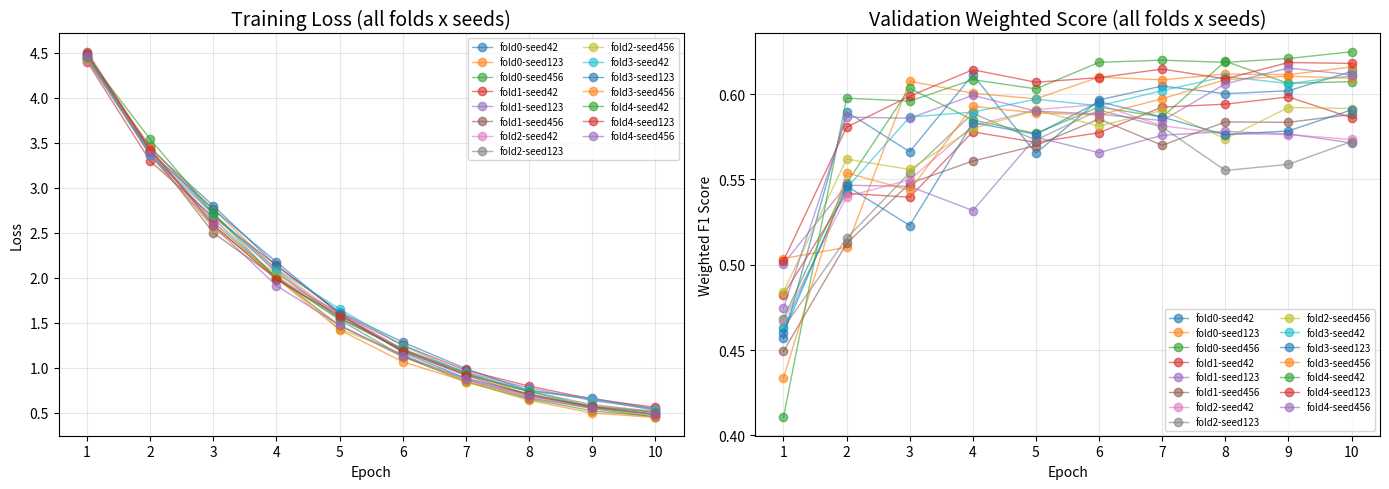

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

for (fold_idx, seed), history in all_histories.items():
    label = f"fold{fold_idx}-seed{seed}"
    axes[0].plot(epochs_range, history["loss"], marker='o', linewidth=1, alpha=0.6, label=label)
    axes[1].plot(epochs_range, history["weighted_score"], marker='o', linewidth=1, alpha=0.6, label=label)

axes[0].set_title("Training Loss (all folds x seeds)", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(epochs_range)
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_title("Validation Weighted Score (all folds x seeds)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Weighted F1 Score")
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(epochs_range)
axes[1].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=150, bbox_inches='tight')
plt.show()

---

## Step 9: 最終評估與結果分析

訓練完成後，載入最佳模型並進行詳細的結果分析。

In [22]:
# ============================================================
# Stacking with LightGBM
# 用 5-Fold OOF 機率（每個 field: 3個seed x n_classes 個機率特徵）
# 訓練一個 LightGBM 分類器作為 Meta Learner
# ============================================================
!pip install lightgbm -q
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

meta_models = {}   # {field: (lgb_model, label_encoder)}

for field in EVAL_FIELDS:
    X = oof_meta_features[field]                 # shape: [n_total, n_classes * 3]
    y_text = oof_true_labels[field]              # 長度 n_total 的文字標籤 list

    # 過濾掉空值/NaN 標籤（跟訓練時一樣的防呆）
    valid_idx = [i for i, v in enumerate(y_text) if v is not None and not (isinstance(v, float) and pd.isna(v)) and v != '']
    X_valid = X[valid_idx]
    y_valid_text = [y_text[i] for i in valid_idx]

    le = LabelEncoder()
    le.fit(list(label2id[field].keys()))   # 固定用 label2id 的順序，避免類別缺失造成編碼不一致
    y_encoded = le.transform(y_valid_text)

    clf = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        verbose=-1
    )
    clf.fit(X_valid, y_encoded)

    meta_models[field] = (clf, le)
    print(f"{field}: Meta Learner 訓練完成 (樣本數: {len(y_valid_text)}, 特徵數: {X_valid.shape[1]})")

print("\n所有 Stacking Meta Learner 訓練完成！")

# ============================================================
# 用 Meta Learner 對 OOF 特徵做最終預測（評估 Stacking 在驗證資料上的表現）
# ============================================================
stacking_preds = []
for i in range(n_total):
    pred = {}
    for field in EVAL_FIELDS:
        clf, le = meta_models[field]
        X_i = oof_meta_features[field][i].reshape(1, -1)
        pred_id = clf.predict(X_i)[0]
        pred[field] = le.inverse_transform([pred_id])[0]
    stacking_preds.append(pred)

# 語意邏輯後處理
for pred in stacking_preds:
    if pred['promise_status'] == 'No':
        pred['verification_timeline'] = 'N/A'
        pred['evidence_status'] = 'N/A'
        pred['evidence_quality'] = 'N/A'
    elif pred['evidence_status'] == 'No':
        pred['evidence_quality'] = 'N/A'

# 評估（用 all_data 當作 ground truth，因為每筆都是某一折的 OOF 預測）
final_results = evaluate_hybrid(all_data, stacking_preds)
final_preds = stacking_preds
val_data = all_data  # 供後續 cell（38, 39）沿用變數名稱

print(f"\n{'=' * 60}")
print(f"最終評估結果（5-Fold x 3-Seed Stacking with LightGBM）")
print(f"{'=' * 60}")
for field in EVAL_FIELDS:
    r = final_results[field]
    print(f"\n--- {field} (權重: {r['weight']}) ---")
    print(r["report"])
    print(f"  Macro F1: {r['macro_f1']:.4f}")
    print(f"  Micro F1: {r['micro_f1']:.4f}")
print(f"\n{'=' * 60}")
print(f"最終加權分數: {final_results['final_weighted_score']:.5f}")
print(f"{'=' * 60}")

promise_status: Meta Learner 訓練完成 (樣本數: 2000, 特徵數: 6)
verification_timeline: Meta Learner 訓練完成 (樣本數: 2000, 特徵數: 15)
evidence_status: Meta Learner 訓練完成 (樣本數: 2000, 特徵數: 9)
evidence_quality: Meta Learner 訓練完成 (樣本數: 2000, 特徵數: 12)

所有 Stacking Meta Learner 訓練完成！

最終評估結果（5-Fold x 3-Seed Stacking with LightGBM）

--- promise_status (權重: 0.2) ---
              precision    recall  f1-score   support

         Yes       0.94      0.97      0.95      1627
          No       0.86      0.71      0.78       373

    accuracy                           0.92      2000
   macro avg       0.90      0.84      0.87      2000
weighted avg       0.92      0.92      0.92      2000

  Macro F1: 0.8657
  Micro F1: 0.9240

--- verification_timeline (權重: 0.15) ---
                       precision    recall  f1-score   support

              already       0.97      0.95      0.96       718
       within_2_years       1.00      0.97      0.99        34
between_2_and_5_years       0.98      0.96      0.97       49

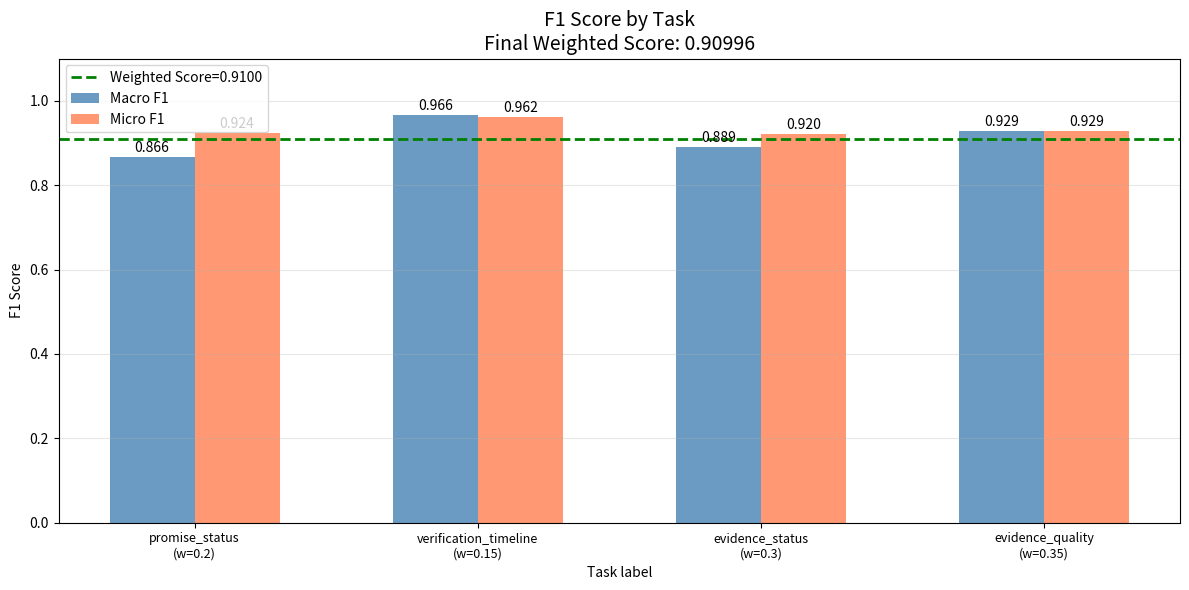

In [23]:
# 視覺化各欄位的 F1 分數
fields = EVAL_FIELDS
macro_f1s = [final_results[f]["macro_f1"] for f in fields]
micro_f1s = [final_results[f]["micro_f1"] for f in fields]
weights   = [FIELD_WEIGHTS[f] for f in fields]

x = range(len(fields))
width = 0.3

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], macro_f1s, width, label='Macro F1', color='steelblue', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], micro_f1s, width, label='Micro F1',  color='coral',     alpha=0.8)

# 加上分數標籤
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xlabel("Task label")
ax.set_ylabel("F1 Score")
ax.set_title(f"F1 Score by Task\nFinal Weighted Score: {final_results['final_weighted_score']:.5f}", fontsize=14, fontweight='bold')
ax.set_xticks(list(x))
ax.set_xticklabels([f"{f}\n(w={w})" for f, w in zip(fields, weights)], fontsize=9)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(final_results["final_weighted_score"], color='green', linestyle='--',
           linewidth=2, label=f"Weighted Score={final_results['final_weighted_score']:.4f}")
ax.legend()

plt.tight_layout()
plt.savefig("f1_scores.png", dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# 儲存預測結果
OUTPUT_PATH = "prediction.json"

output_data = []
for orig, pred in zip(val_data, final_preds):
    item = dict(orig)   # 複製原始資料
    item.update(pred)   # 覆蓋預測欄位
    output_data.append(item)

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output_data, f, ensure_ascii=False, indent=2)

print(f"✅ 預測結果已儲存至: {OUTPUT_PATH}")
print(f"   共 {len(output_data)} 筆")

# 顯示前3筆預測結果
print("\n📋 前3筆預測結果：")
for i, item in enumerate(output_data[:3]):
    print(f"\n--- 第{i+1}筆 (ID: {item.get('id', 'N/A')}) ---")
    for field in EVAL_FIELDS:
        print(f"  {field}: {item[field]}")

✅ 預測結果已儲存至: prediction.json
   共 2000 筆

📋 前3筆預測結果：

--- 第1筆 (ID: 10001) ---
  promise_status: Yes
  verification_timeline: already
  evidence_status: No
  evidence_quality: N/A

--- 第2筆 (ID: 10002) ---
  promise_status: Yes
  verification_timeline: between_2_and_5_years
  evidence_status: No
  evidence_quality: N/A

--- 第3筆 (ID: 10003) ---
  promise_status: Yes
  verification_timeline: between_2_and_5_years
  evidence_status: Yes
  evidence_quality: Not Clear


---

## Step 10: 進階改進方向

恭喜你完成了基礎版本！以下是幾個可以進一步提升分數的方向：

### 1. 模型升級
```python
# 可以嘗試更大的模型
MODEL_NAME = "hfl/chinese-roberta-wwm-ext-large"  # 中文 RoBERTa Large
MODEL_NAME = "bert-large-chinese"                   # BERT Large
```

### 2. 加入 Dropout 防止過擬合
```python
self.dropout = nn.Dropout(0.1)
pooled = self.dropout(outputs.pooler_output)
```

### 3. 損失加權（針對類別不均衡）
```python
# 給少數類別更高的損失權重
criterion = nn.CrossEntropyLoss(weight=class_weights)
```

### 4. 資料增強
- 同義詞替換
- 回譯（中→英→中）
- 隨機遮罩

### 5. 集成學習（Ensemble）
```python
# 訓練多個模型，取預測結果的多數票
from collections import Counter
ensemble_pred = Counter([model1_pred, model2_pred, model3_pred]).most_common(1)[0][0]
```

### 6. 調整超參數
- 增加 Epochs（10-15）
- 調整 Learning Rate（1e-5 ~ 5e-5）
- 增大 MAX_LEN（512）
- 嘗試不同 BATCH_SIZE

---
## 工作坊總結

今天我們學習了：
1. ESG 承諾驗證任務的定義
2. 使用 EDA 分析資料分佈
3. 實作 PyTorch Dataset & DataLoader
4. 設計 Multi-Task BERT 模型架構
5. 完整的訓練、評估、預測流程
6. 使用加權 Macro F1 評分

**祝大家在比賽中取得好成績！**

In [25]:
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm import tqdm
import json
from torch.utils.data import Dataset, DataLoader

# --- 步驟 1: 讀取測試集檔案 ---
test_df = pd.read_csv("/kaggle/input/datasets/raingarden/dataset-1/csv/vpesg4k_test_2000.csv")
for field in ['verification_timeline', 'evidence_status', 'evidence_quality']:
    if field in test_df.columns:
        test_df[field] = test_df[field].fillna('N/A')

print(f"成功載入！資料筆數：{len(test_df)}")
# 將 DataFrame 轉成 List of Dictionaries
test_data_list = test_df.to_dict('records')

# --- 步驟 2: 定義測試集 Dataset ---
class TestDataset(Dataset):
    def __init__(self, data_list, tokenizer, max_len=512):
        self.data = data_list 
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        sample = self.data[idx]
        text = sample['data'] # 完美對應你的 JSON 欄位

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )

        # 抓取題號，防呆機制
        item_id = sample.get('id', idx) 

        return {
            'id': item_id,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

# --- 步驟 3: 建立 DataLoader ---
test_dataset = TestDataset(test_data_list, tokenizer, max_len=MAX_LEN)
test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn 
)

# ============================================================
# 步驟 4: 用全部 5-Fold x 3-Seed = 15 個模型，對測試集輸出機率
# 每個 field 拼出 [n_test, n_classes * 3] 的特徵（跟 OOF 特徵結構一致）
# 然後用 fold 各自的 LightGBM 機率取平均，或直接平均 15 個模型再餵入 LightGBM
# ============================================================
n_test = len(test_data_list)

# 先收集每個 (fold, seed) 模型的 test 機率
all_test_probs = {}  # {(fold, seed): {field: [n_test, n_classes]}}
for fold_idx in range(N_FOLDS):
    for seed in SEEDS:
        model.load_state_dict(torch.load(f"best_model_fold{fold_idx}_seed{seed}.pt", map_location=device))
        model.eval()
        probs = predict_proba(model, test_loader, device)
        all_test_probs[(fold_idx, seed)] = probs
        print(f"Fold {fold_idx} | Seed {seed} 測試集機率預測完成")

# 對每個 field：依 seed 平均掉 5 個 fold 的機率（fold 是 K-Fold 重複的同類模型，取平均更穩定）
# 再拼成 [n_test, n_classes * 3]（3 個 seed）餵給對應的 LightGBM
test_meta_features = {field: np.zeros((n_test, num_labels[field] * len(SEEDS))) for field in EVAL_FIELDS}

for field in EVAL_FIELDS:
    n_classes = num_labels[field]
    for seed_pos, seed in enumerate(SEEDS):
        # 平均同一個 seed、不同 fold 的機率
        seed_probs = np.mean(
            [all_test_probs[(fold_idx, seed)][field] for fold_idx in range(N_FOLDS)],
            axis=0
        )  # shape: [n_test, n_classes]
        col_start = seed_pos * n_classes
        col_end = col_start + n_classes
        test_meta_features[field][:, col_start:col_end] = seed_probs

# --- 步驟 5: 用訓練好的 LightGBM Meta Learner 做最終預測 ---
final_preds = []
for i in range(n_test):
    pred = {}
    for field in EVAL_FIELDS:
        clf, le = meta_models[field]
        X_i = test_meta_features[field][i].reshape(1, -1)
        pred_id = clf.predict(X_i)[0]
        pred[field] = le.inverse_transform([pred_id])[0]
    final_preds.append(pred)

# --- 步驟 6: 語意邏輯後處理 ---
for pred in final_preds:
    if pred['promise_status'] == 'No':
        pred['verification_timeline'] = 'N/A'
        pred['evidence_status'] = 'N/A'
        pred['evidence_quality'] = 'N/A'
    elif pred['evidence_status'] == 'No':
        pred['evidence_quality'] = 'N/A'

# --- 步驟 7: 存檔 ---
submission_df = pd.DataFrame({
    'id': [s['id'] for s in test_data_list],
    **{field: [p[field] for p in final_preds] for field in EVAL_FIELDS}
})
submission_df.to_csv('submission.csv', index=False)
print(f"\n✅ 大功告成！預測結果已存至 submission.csv，共 {len(submission_df)} 筆資料。")

成功載入！資料筆數：2000
Fold 0 | Seed 42 測試集機率預測完成
Fold 0 | Seed 123 測試集機率預測完成
Fold 0 | Seed 456 測試集機率預測完成
Fold 1 | Seed 42 測試集機率預測完成
Fold 1 | Seed 123 測試集機率預測完成
Fold 1 | Seed 456 測試集機率預測完成
Fold 2 | Seed 42 測試集機率預測完成
Fold 2 | Seed 123 測試集機率預測完成
Fold 2 | Seed 456 測試集機率預測完成
Fold 3 | Seed 42 測試集機率預測完成
Fold 3 | Seed 123 測試集機率預測完成
Fold 3 | Seed 456 測試集機率預測完成
Fold 4 | Seed 42 測試集機率預測完成
Fold 4 | Seed 123 測試集機率預測完成
Fold 4 | Seed 456 測試集機率預測完成

✅ 大功告成！預測結果已存至 submission.csv，共 2000 筆資料。
